In [1]:
!python -V

Python 3.9.7


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
import pickle


In [13]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

2026/08/11 03:19:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 03:19:00 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/home/ubuntu/mlps-zoomcap/src/03-training/experiment_tracking/mlruns/1', creation_time=1786163367345, experiment_id='1', last_update_time=1786163367345, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [58]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,0.50,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,0.50,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,0.50,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,0.50,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,0.00,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,2.75,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,0.00,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,2.75,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,2.75,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN


In [3]:

def read_dataframe(fileName):
    df = pd.read_parquet(fileName)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    
    df['duration'] =  df.lpep_dropoff_datetime  - df.lpep_pickup_datetime 
    
    df.duration = df.duration.apply(lambda td: td.total_seconds()/60)
    df = df[(df.duration >= 1) & (df.duration <= 60)]
    
    categorical =  ['PULocationID', 'DOLocationID']

    df[categorical] = df[categorical].astype(str)

    return df

In [4]:
df_train = read_dataframe('data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('data/green_tripdata_2021-02.parquet')

In [5]:
df_train['PU_DO'] = df_train['PULocationID']+ '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID']+ '_' + df_val['DOLocationID']

In [6]:
df_val

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration,PU_DO
0,2,2021-02-01 00:34:03,2021-02-01 00:51:58,N,1.0,130,205,5.0,3.66,14.00,...,10.00,0.0,None,0.3,25.30,1.0,1.0,0.00,17.916667,130_205
1,2,2021-02-01 00:04:00,2021-02-01 00:10:30,N,1.0,152,244,1.0,1.10,6.50,...,0.00,0.0,None,0.3,7.80,2.0,1.0,0.00,6.500000,152_244
2,2,2021-02-01 00:18:51,2021-02-01 00:34:06,N,1.0,152,48,1.0,4.93,16.50,...,0.00,0.0,None,0.3,20.55,2.0,1.0,2.75,15.250000,152_48
3,2,2021-02-01 00:53:27,2021-02-01 01:11:41,N,1.0,152,241,1.0,6.70,21.00,...,0.00,0.0,None,0.3,22.30,2.0,1.0,0.00,18.233333,152_241
4,2,2021-02-01 00:57:46,2021-02-01 01:06:44,N,1.0,75,42,1.0,1.89,8.50,...,2.45,0.0,None,0.3,12.25,1.0,1.0,0.00,8.966667,75_42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64567,2,2021-02-28 22:19:00,2021-02-28 22:29:00,None,NaN,129,7,NaN,2.63,10.04,...,0.00,0.0,None,0.3,10.34,NaN,NaN,NaN,10.000000,129_7
64568,2,2021-02-28 23:18:00,2021-02-28 23:27:00,None,NaN,116,166,NaN,1.87,8.33,...,1.89,0.0,None,0.3,10.52,NaN,NaN,NaN,9.000000,116_166
64569,2,2021-02-28 23:44:00,2021-02-28 23:58:00,None,NaN,74,151,NaN,2.40,12.61,...,0.00,0.0,None,0.3,12.91,NaN,NaN,NaN,14.000000,74_151
64570,2,2021-02-28 23:07:00,2021-02-28 23:14:00,None,NaN,42,42,NaN,1.11,11.95,...,0.00,0.0,None,0.3,15.00,NaN,NaN,NaN,7.000000,42_42


In [7]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records') 

X_val = dv.transform(val_dicts)


In [6]:
categorical = ['PU_DO']
numerical = ['trip_distance']
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records') 

X_val = dv.transform(val_dicts)

In [7]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values


In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print(rmse)

7.758715200888857


In [13]:
with open('models/linear_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [8]:
with mlflow.start_run():
    mlflow.set_tag("developer", "german")
    mlflow.log_param("train-data-path", "data/green_tripdata_2021-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2021-02.parquet")
    alpha = 0.01
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)

    rmse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(rmse)

    mlflow.log_metric("rmse", rmse)
    mlflow.log_artifact(local_path="models/linear_reg.bin", artifact_path="models_pickle")
    print(rmse)

11.167275941179728


In [8]:
import xgboost as xgb

In [9]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

/home/ubuntu/anaconda3/envs/enviromen3.9/lib/python3.9/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [14]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(rmse)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

Parameter
Value
learning_rate
0.5505807072411215
max_depth
28
min_child_weight
3.473251942835388
objective
reg:linear
reg_alpha
0.008381713732230794
reg_lambda
0.15043065134872904
seed
42

In [ ]:
params = {
    'learning_rate': 0.5505807072411215,
    'max_depth': 28,
    'min_child_weight': 3.473251942835388,
    'objective': 'reg:linear',
    'reg_alpha': 0.008381713732230794,
    'reg_lambda': 0.15043065134872904,
    'seed': 42
}


mlflow.xgboost.autolog()
booster = xgb.train(
    params=params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, 'validation')],
    early_stopping_rounds=50
)

In [15]:
best_params = {
    'learning_rate': 0.5505807072411215,
    'max_depth': 28,
    'min_child_weight': 3.473251942835388,
    'objective': 'reg:linear',
    'reg_alpha': 0.008381713732230794,
    'reg_lambda': 0.15043065134872904,
    'seed': 42
}


mlflow.log_params(best_params)
booster = xgb.train(
    params=best_params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, 'validation')],
    early_stopping_rounds=50
)

y_pred = booster.predict(valid)
rmse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(rmse)
mlflow.log_metric("rmse", rmse)

with open("models/preprocessor.b", "wb") as f_out:
    pickle.dump(dv, f_out)
    
mlflow.log_artifact(local_path="models/preprocessor.b", artifact_path="preprocessor")
mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

/home/ubuntu/anaconda3/envs/enviromen3.9/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [03:19:20] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation-rmse:8.25670
[1]	validation-rmse:7.07051
[2]	validation-rmse:6.73424
[3]	validation-rmse:6.62091
[4]	validation-rmse:6.57659
[5]	validation-rmse:6.55447
[6]	validation-rmse:6.54234
[7]	validation-rmse:6.53199
[8]	validation-rmse:6.52527
[9]	validation-rmse:6.52232
[10]	validation-rmse:6.51465
[11]	validation-rmse:6.51159
[12]	validation-rmse:6.50736
[13]	validation-rmse:6.50393
[14]	validation-rmse:6.49880
[15]	validation-rmse:6.49614
[16]	validation-rmse:6.49355
[17]	validation-rmse:6.49001
[18]	validation-rmse:6.48577
[19]	validation-rmse:6.48414
[20]	validation-rmse:6.47885
[21]	validation-rmse:6.47507
[22]	validation-rmse:6.47138
[23]	validation-rmse:6.46827
[24]	validation-rmse:6.46571
[25]	validation-rmse:6.46277
[26]	validation-rmse:6.46158
[27]	validation-rmse:6.45902
[28]	validation-rmse:6.45704
[29]	validation-rmse:6.45468
[30]	validation-rmse:6.45386
[31]	validation-rmse:6.45236
[32]	validation-rmse:6.45035
[33]	validation-rmse:6.44807
[34]	validation-rmse:6.4

2026/08/11 03:19:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/ubuntu/anaconda3/envs/enviromen3.9/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [03:19:44] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/08/11 03:19:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [16]:
logged_model= "runs:/12562b70b2b04f36853832d97f62cd7a/models_mlflow"

loaded_model = mlflow.xgboost.load_model(logged_model)



In [ ]:
loaded_model

In [ ]:
loaded_model.predict(pd.DataFrame(X_val))

In [61]:
lr = Ridge(alpha=0.001)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print(rmse)

7.520393154812667


In [16]:
y_train

array([ 3.93333333,  8.75      ,  5.96666667, ..., 11.        ,
       27.        , 10.        ])

LinearRegression()

/tmp/ipykernel_2246/4124956464.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_2246/4124956464.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


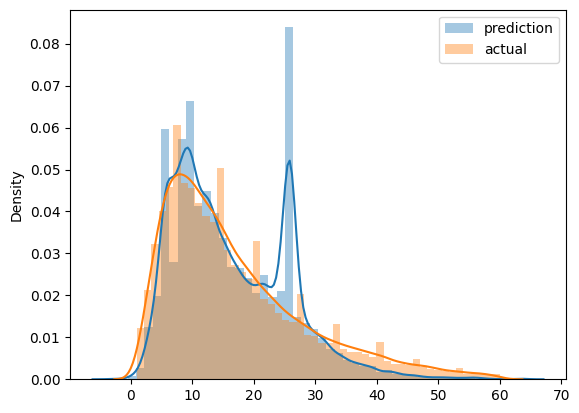

In [11]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
plt.legend()


9.838799799829628

In [148]:
lr = LinearRegression()
lr.fit(X_train, y_train)

1.6.1
(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')


In [ ]:
y_pred = lr.predict(X_train)